<div align="center">  

# Projet MMSN – Dynamique de Population  

## Modèle de Lotka-Volterra et Modèle Logistique à deux espèces  
## Résolution Numérique par la Méthode de Runge-Kutta d’ordre 4  

</div>  

**INSA Rouen**  
**Étudiant : Duy NGO TAN MINH**  
**Étudiant : Hung NGUYEN MANH**  
**Année    : GM3**  

---

## I. Objectif du projet

L’objectif de ce projet est d’étudier numériquement deux modèles de dynamique de population :

- Le Modèle de Lotka-Volterra, qui décrit l’interaction entre proies et prédateurs,
- Le Modèle Logistique à deux espèces, qui décrit une interaction de compétition interspécifique.

Pour ces deux modèles, nous utilisons la Méthode de Runge-Kutta d’ordre 4 afin d’approcher les solutions numériques.

Nous analysons ensuite :
- Le comportement des solutions obtenues,
- L’influence du pas de discrétisation,
- La cohérence des résultats numériques avec les comportements théoriques attendus.

## II. Modèle mathématique de Lotka-Volterra

Le modèle de Lotka-Volterra décrit l’évolution dynamique de deux populations en interaction : les proies et les prédateurs.

Le système différentiel s’écrit :

$$
\frac{dN}{dt} = rN - \alpha N P
$$

$$
\frac{dP}{dt} = \beta N P - dP
$$

où :

- $N(t)$ désigne la population de proies à l’instant $t$,
- $P(t)$ désigne la population de prédateurs à l’instant $t$,
- $r$ est le taux de croissance naturel des proies en l’absence de prédateurs,
- $\alpha$ représente le taux de prédation (interaction entre proies et prédateurs),
- $\beta$ est le taux de reproduction des prédateurs proportionnel à la consommation de proies,
- $d$ est le taux de mortalité naturel des prédateurs.

Ce modèle met en évidence un comportement oscillatoire caractéristique des systèmes proies-prédateurs.

In [9]:
# IMPORTS
import numpy as np
import matplotlib.pyplot as plt
import time

In [10]:
def lotka_volterra(t, y, r, alpha, beta, d):
    N, P = y
    dNdt = r * N - alpha * N * P
    dPdt = beta * N * P - d * P
    return np.array([dNdt, dPdt])

## III. Méthode Numérique : Runge-Kutta d’ordre 4

Pour résoudre numériquement les systèmes étudiés, nous utilisons la méthode de Runge-Kutta d’ordre 4 (RK4).  

Cette méthode explicite permet d’obtenir une bonne précision numérique tout en restant simple à implémenter.  

La même méthode est appliquée aux deux modèles afin de comparer leurs comportements dynamiques dans un cadre numérique commun.  

In [11]:
def rk4(f, t0, y0, T, h, params):
    n = int((T - t0) / h)

    t = np.zeros(n + 1)
    y = np.zeros((n + 1, len(y0)))

    t[0] = t0
    y[0] = y0

    for i in range(n):
        k1 = f(t[i], y[i], *params)
        k2 = f(t[i] + h/2, y[i] + h*k1/2, *params)
        k3 = f(t[i] + h/2, y[i] + h*k2/2, *params)
        k4 = f(t[i] + h, y[i] + h*k3, *params)

        y[i+1] = y[i] + (h/6)*(k1 + 2*k2 + 2*k3 + k4)
        t[i+1] = t[i] + h

    return t, y

In [12]:
# Parametres that we will change to analyze the model later
r = 1.0
alpha = 0.1
beta = 0.075
d = 1.5

y0 = np.array([10.0, 5.0])

t0 = 0.0
T = 60.0
h = 0.01    # Time step

params = (r, alpha, beta, d)

In [13]:
start = time.perf_counter()
t, y = rk4(lotka_volterra, t0, y0, T, h, params)
elapsed = time.perf_counter() - start

N = y[:, 0]
P = y[:, 1]

print(f"Execution time: {elapsed:.6f} s")

Execution time: 0.332590 s


## 1. Dynamique du Modèle de Lotka-Volterra

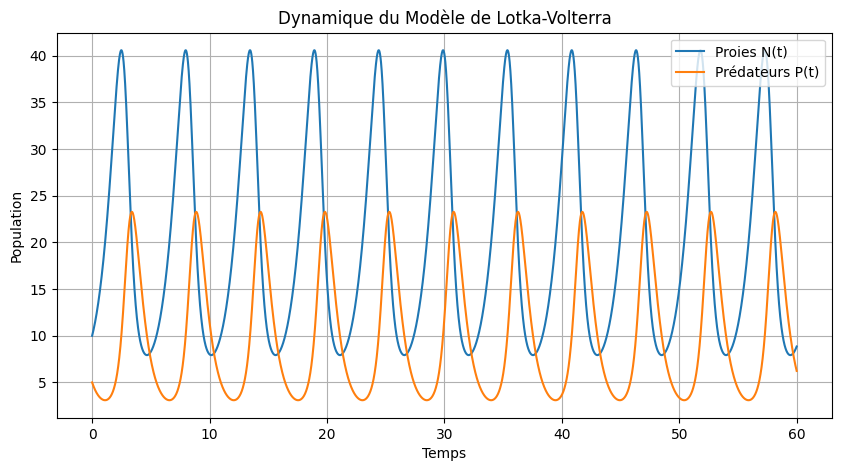

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(t, N, label = "Proies N(t)")
plt.plot(t, P, label = "Prédateurs P(t)")
plt.xlabel("Temps")
plt.ylabel("Population")
plt.title("Dynamique du Modèle de Lotka-Volterra")
plt.legend()
plt.grid(True)
plt.show()

Observation :
- Oscillations périodiques des deux populations.
- Déphasage : les prédateurs suivent les proies.

## 2. Portrait de phase du Modèle de Lotka-Volterra

## Point d’équilibre du modèle de Lotka–Volterra

Le système de Lotka–Volterra classique admet un point d’équilibre non trivial donné par :

$$
E^* = \left( \frac{d}{\beta}, \frac{r}{\alpha} \right)
$$

- Ce point correspond à une situation où les populations de proies et de prédateurs restent constantes dans le temps.

- Autour de ce point, le système présente des oscillations périodiques. 
Le portrait de phase montre des trajectoires fermées, indiquant que l’équilibre est un centre (et non un attracteur).

- Cela signifie que le système ne converge pas vers l’équilibre, mais oscille indéfiniment autour de celui-ci.

- Dans la simulation numérique, ce point est représenté sur le graphique afin de vérifier la cohérence entre les résultats numériques et la théorie.

In [15]:
# Equilibre theorique
N_star = d / beta
P_star = r / alpha
print(N_star)
print(P_star)

20.0
10.0


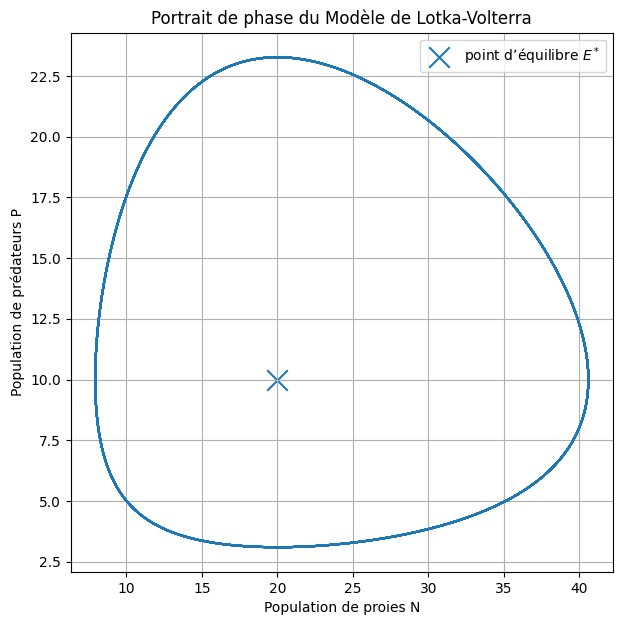

In [16]:
plt.figure(figsize=(7, 7))
plt.plot(N, P)
plt.xlabel("Population de proies N")
plt.ylabel("Population de prédateurs P")
plt.title("Portrait de phase du Modèle de Lotka-Volterra")
plt.scatter(N_star, P_star, marker='x', s=219, label=r"point d’équilibre $E^*$")
plt.legend()
plt.grid(True)
plt.show()

Observation: 
- Le point d’équilibre $E^*$ est bien situé à l’intérieur de la trajectoire.

- Bien que ce point ne corresponde pas au centre géométrique de la courbe, il représente un centre dynamique du système.

- Les trajectoires du portrait de phase oscillent autour de ce point, ce qui est conforme au comportement théorique du modèle de Lotka–Volterra classique.

## 3. Influence du pas de discrétisation

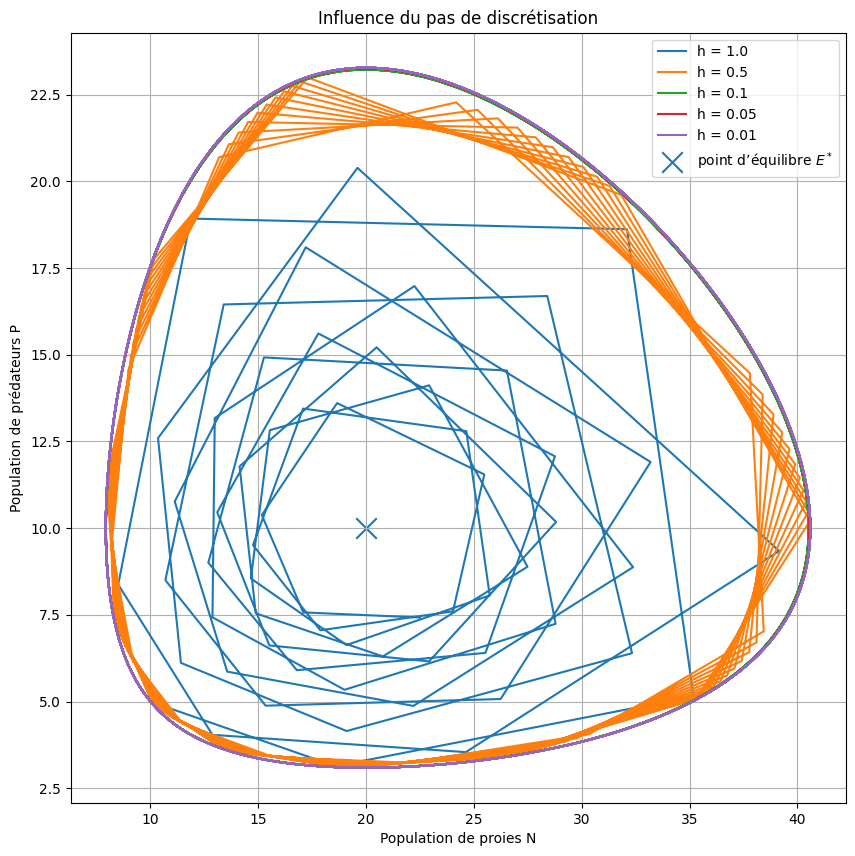

In [17]:
steps = [1.0, 0.5, 0.1, 0.05, 0.01]

plt.figure(figsize=(10, 10))

for h_test in steps:
    t, y = rk4(lotka_volterra, t0, y0, T, h_test, params)
    plt.plot(y[:, 0], y[:, 1], label = f"h = {h_test}")

plt.xlabel("Population de proies N")
plt.ylabel("Population de prédateurs P")
plt.title("Influence du pas de discrétisation")
plt.scatter(N_star, P_star, marker='x', s=219, label=r"point d’équilibre $E^*$")
plt.legend()
plt.grid(True)
plt.show()

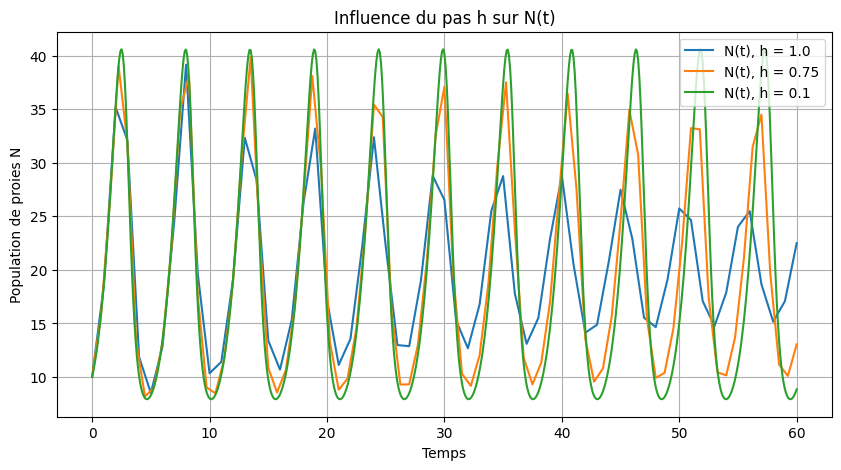

In [18]:
steps = [1.0, 0.75, 0.1]

plt.figure(figsize=(10, 5))

for h_test in steps:
    t_temp, y_temp = rk4(lotka_volterra, t0, y0, T, h_test, params)
    plt.plot(t_temp, y_temp[:, 0], label=f"N(t), h = {h_test}")
plt.xlabel("Temps")
plt.ylabel("Population de proies N")
plt.title("Influence du pas h sur N(t)")
plt.legend()
plt.grid(True)
plt.show()

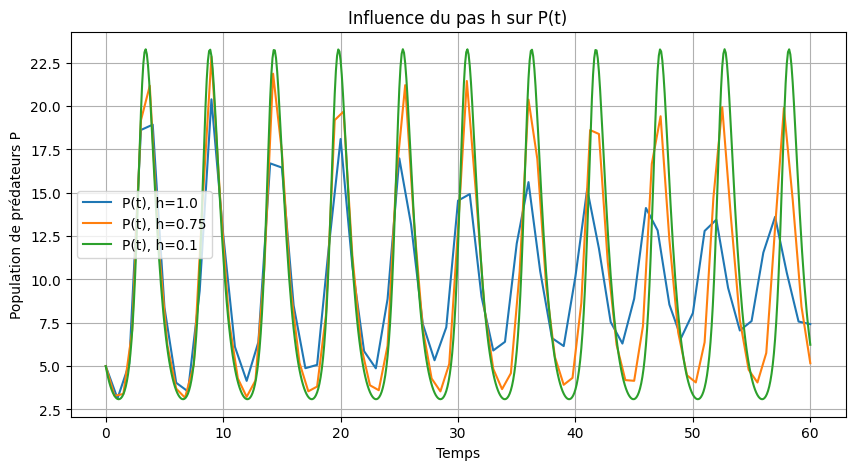

In [19]:
plt.figure(figsize=(10, 5))

for h_test in steps:
    t_temp, y_temp = rk4(lotka_volterra, t0, y0, T, h_test, params)
    plt.plot(t_temp, y_temp[:, 1], label=f"P(t), h={h_test}")
plt.xlabel("Temps")
plt.ylabel("Population de prédateurs P")
plt.title("Influence du pas h sur P(t)")
plt.legend()
plt.grid(True)
plt.show()

Observation:
- Les solutions convergent lorsque h diminue.
- RK4 est stable pour des pas raisonnables.

## 4. Influence des conditions initiales

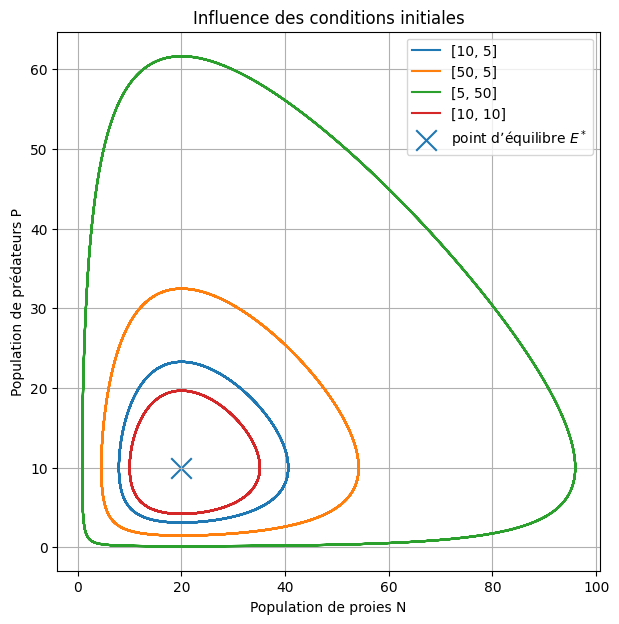

In [20]:
plt.figure(figsize=(7, 7))

tests = [[10,5], [50,5], [5,50], [10,10]]

for y0_test in tests:
    t, y = rk4(lotka_volterra, t0, y0_test, T, h, params)
    plt.plot(y[:,0], y[:,1], label = str(y0_test))

plt.xlabel("Population de proies N")
plt.ylabel("Population de prédateurs P")
plt.title("Influence des conditions initiales")
plt.scatter(N_star, P_star, marker='x', s=219, label="point d’équilibre $E^*$")
plt.legend()
plt.grid(True)
plt.show()

Observation :
- Les trajectoires restent périodiques.
- Chaque condition initiale définit une orbite différente.

## 5. Influence du taux de prédation (interaction entre proies et prédateurs)

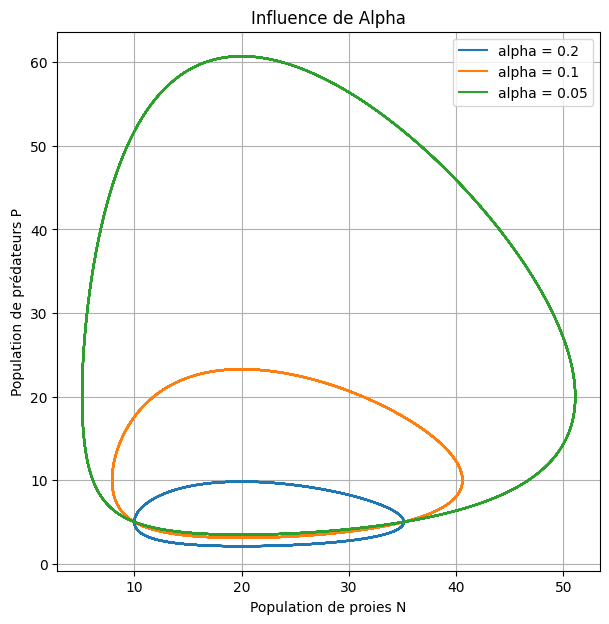

In [21]:
plt.figure(figsize=(7, 7))

alphas = [0.2, 0.1, 0.05]

for alpha_test in alphas:
    t, y = rk4(lotka_volterra, t0, y0, T, h, (r, alpha_test, beta, d))
    plt.plot(y[:,0], y[:,1], label = f"alpha = {alpha_test}")

plt.xlabel("Population de proies N")
plt.ylabel("Population de prédateurs P")
plt.title("Influence de Alpha")
plt.legend()
plt.grid(True)
plt.show()

Observation :
- Une prédation plus forte réduit la population de proies.
- L’orbite est modifiée (déformation du cycle).

## 6. Influence du taux de croissance naturel des proies

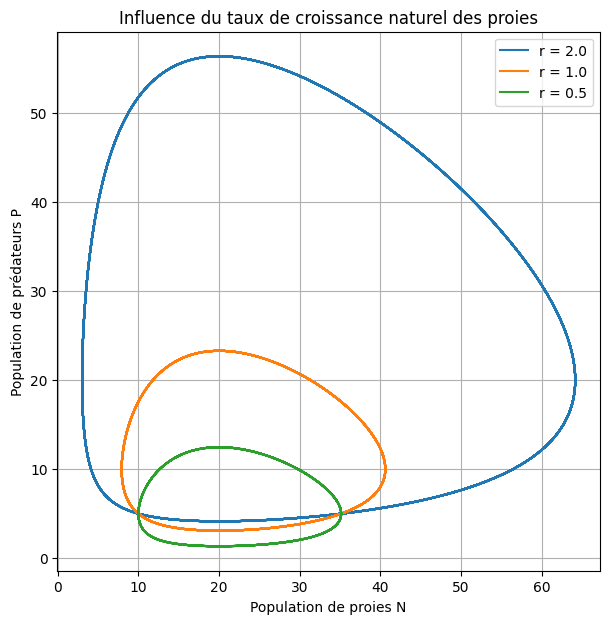

In [22]:
plt.figure(figsize=(7, 7))

grows_prey = [2.0, 1.0, 0.5]

for grow_prey in grows_prey:
    t, y = rk4(lotka_volterra, t0, y0, T, h, (grow_prey, alpha, beta, d))
    plt.plot(y[:,0], y[:,1], label = f"r = {grow_prey}")

plt.xlabel("Population de proies N")
plt.ylabel("Population de prédateurs P")
plt.title("Influence du taux de croissance naturel des proies")
plt.legend()
plt.grid(True)
plt.show()

Observation: 
- Lorsque r augmente, les proies ont tendance à croître plus rapidement dans les phases où les prédateurs sont peu nombreux.

- Cela entraîne ensuite une augmentation de la population de prédateurs dans les phases suivantes.

- Le système conserve un comportement cyclique, mais l’amplitude des trajectoires (dans l’espace des phases) est modifiée.

## 7. Influence du taux de mortalité naturel des prédateurs

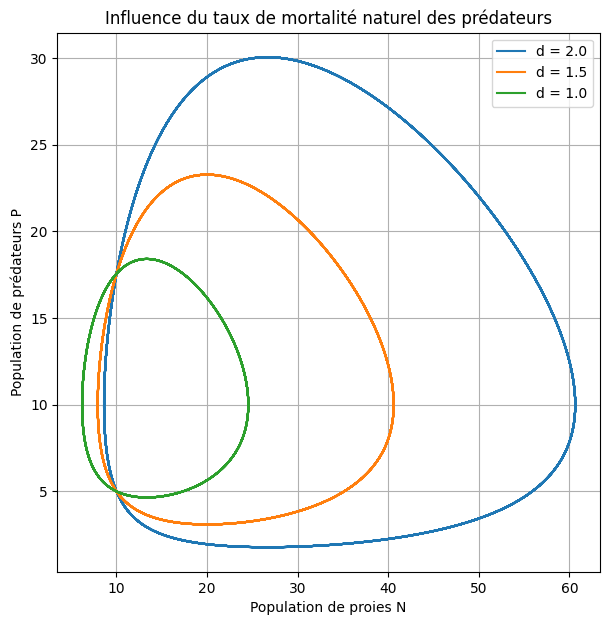

In [23]:
plt.figure(figsize=(7, 7))

deaths_pred = [2.0, 1.5, 1.0]

for death_pred in deaths_pred:
    t, y = rk4(lotka_volterra, t0, y0, T, h, (r, alpha, beta, death_pred))
    plt.plot(y[:,0], y[:,1], label = f"d = {death_pred}")

plt.xlabel("Population de proies N")
plt.ylabel("Population de prédateurs P")
plt.title("Influence du taux de mortalité naturel des prédateurs")
plt.legend()
plt.grid(True)
plt.show()

Observation: 
- Lorsque d augmente, la mortalité des prédateurs devient plus importante, ce qui réduit la pression de prédation.

- Cela permet aux proies de se développer davantage, entraînant ensuite une augmentation des prédateurs lors des phases suivantes.

- Le système reste cyclique, mais les trajectoires s’élargissent, indiquant une augmentation de l’amplitude des oscillations.

## 8. Influence du taux de reproduction des prédateurs proportionnel à la consommation de proies

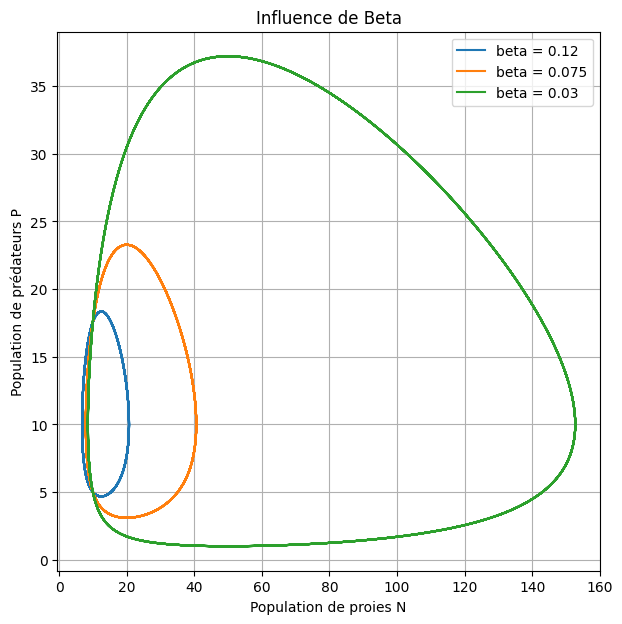

In [24]:

plt.figure(figsize=(7, 7))

betas = [0.12, 0.075, 0.03]

for beta_test in betas: 
    t, y = rk4(lotka_volterra, t0, y0, T, h, (r, alpha, beta_test, d))
    plt.plot(y[:,0], y[:,1], label = f"beta = {beta_test}")

plt.xlabel("Population de proies N")
plt.ylabel("Population de prédateurs P")
plt.title("Influence de Beta")
plt.legend()
plt.grid(True)
plt.show()

Observation: 
- Lorsque β augmente (efficacité de conversion des proies en prédateurs), les prédateurs croissent plus rapidement dès que des proies sont disponibles.

- Cela intensifie la pression de prédation, limitant ainsi la croissance des proies.

- Le système reste cyclique, mais les trajectoires se contractent, traduisant une diminution de l’amplitude des oscillations.

## 9. Analyse de convergence de la Méthode de Runge-Kutta d’ordre 4

In [25]:
from scipy.interpolate import interp1d
import pandas as pd

In [26]:
step_values = [0.2, 0.1, 0.05, 0.025, 0.0125] 
errors = []
times = []

# Reference solution
step_ref = 0.001
t_ref, sol_ref = rk4(lotka_volterra, t0, y0, T, step_ref, params)

# Em tao ham interpolation (vector-valued)
# Interpolation function
interp_func = interp1d(
    t_ref,
    sol_ref,
    axis=0,
    kind='cubic',
    bounds_error=False,
    fill_value="extrapolate"
)

for step_value in step_values:
    start = time.perf_counter()
    
    t, sol = rk4(lotka_volterra, t0, y0, T, step_value, params)
    
    elapsed = time.perf_counter() - start
    times.append(elapsed)

    # Inperpolate sol_ref at the exact grid
    ref_interp = interp_func(t)
    
    # Error
    error = np.max(np.abs(sol - ref_interp))
    errors.append(error)

In [27]:

df = pd.DataFrame({
    "h": step_values,
    "Erreur max": errors,
    "Temps (s)": times
})

df

,h,Erreur max,Temps (s)
0,0.2000,2.931173e-02,0.017170
1,0.1000,2.905251e-03,0.030791
2,0.0500,2.122784e-04,0.061487
3,0.0250,1.419099e-05,0.137386
4,0.0125,9.167560e-07,0.250204


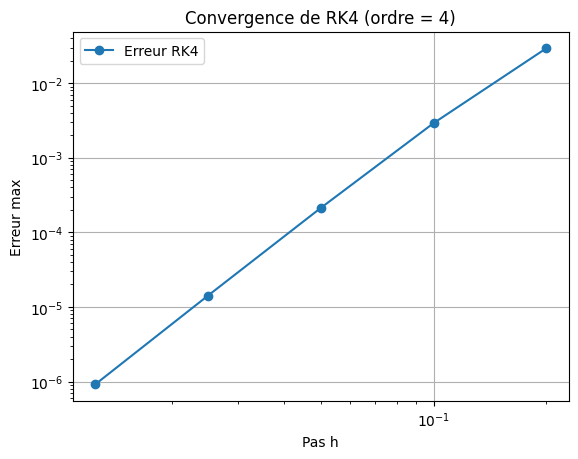

In [28]:
plt.loglog(step_values, errors, 'o-', label="Erreur RK4")
plt.xlabel("Pas h")
plt.ylabel("Erreur max")
plt.title("Convergence de RK4 (ordre = 4)")
plt.grid(True)
plt.legend()
plt.show()

Analyse de convergence de RK4:

- Lorsque le pas h diminue, la solution numérique se rapproche de la solution de référence.
- L’erreur maximale décroît nettement avec h, ce qui confirme la bonne précision de la méthode RK4.
- Le graphique en échelle log-log présente une pente proche de 4. L’ordre estimé confirme que la méthode RK4 est d’ordre 4.
- En revanche, le temps de calcul augmente lorsque h diminue, car le nombre d’itérations devient plus grand. On observe donc un compromis classique entre précision numérique et coût de calcul.
- Pour un pas trop grand, la trajectoire peut être déformée et perdre le comportement périodique attendu.
- Le choix du pas influence fortement précision et coût.

## IV. Conclusion des résultats du Modèle de Lotka-Volterra

- On observe un comportement oscillatoire des deux populations.

- Lorsque la population de proies augmente, la population de prédateurs augmente avec un certain retard. L’augmentation de la population des prédateurs entraîne une diminution de la population des proies. Ensuite, la diminution des proies entraîne une diminution des prédateurs.

- La comparaison des différents pas montre que:
    - un pas plus petit donne une solution plus précise.
    - un pas plus grand peut déformer les trajectoires.

## V. Modèle Logistique à deux espèces

Contrairement au modèle de Lotka-Volterra, ce modèle décrit une interaction de type compétition entre deux espèces.

Chaque population évolue selon une croissance logistique limitée par une capacité de charge, tout en subissant l’influence de l’autre espèce.

Le système différentiel s’écrit :

$$
\frac{dN_1}{dt} = r_1 N_1 \left(1 - \frac{N_1 + a_{12} N_2}{K_1}\right)
$$

$$
\frac{dN_2}{dt} = r_2 N_2 \left(1 - \frac{N_2 + a_{21} N_1}{K_2}\right)
$$

où :

- $N_1(t)$ et $N_2(t)$ sont les populations des deux espèces,
- $r_1, r_2$ sont les taux de croissance,
- $K_1, K_2$ sont les capacités de charge (carrying capacity),
- $a_{12}, a_{21}$ représentent l’effet de compétition interspécifique.

Ce modèle peut conduire soit à la coexistence des deux espèces, soit à l’exclusion de l’une d’elles.

In [29]:
def logistic_two_species(t, y, r1, r2, K1, K2, a12, a21):
    N1, N2 = y

    dN1dt = r1 * N1 * (1 - (N1 + a12 * N2) / K1)
    dN2dt = r2 * N2 * (1 - (N2 + a21 * N1) / K2)

    return np.array([dN1dt, dN2dt])

In [30]:
# Parametres that we will change to analyze the model later
r1 = 0.8
r2 = 0.6
K1 = 50.0
K2 = 40.0
a12 = 0.5
a21 = 0.4

# Condition initiale
y0_log = np.array([10.0, 8.0])

# Temps
t0 = 0.0
T = 50.0
h = 0.01    # Time step

params_log = (r1, r2, K1, K2, a12, a21)

In [31]:
start = time.perf_counter()

t_log, y_log = rk4(logistic_two_species, t0, y0_log, T, h, params_log)

elapsed = time.perf_counter() - start

N1 = y_log[:, 0]
N2 = y_log[:, 1]

print(f"Execution time: {elapsed:.6f} s")

Execution time: 0.253044 s


## 1. Dynamique du Modèle Logistique à deux espèces

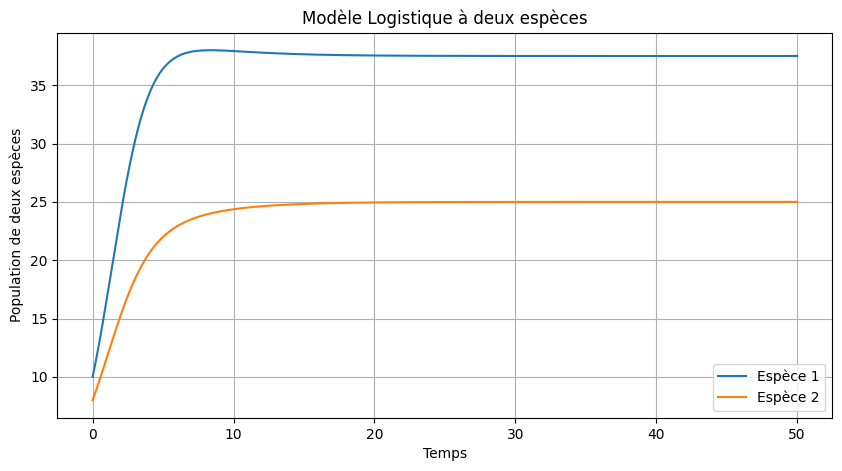

In [32]:
plt.figure(figsize=(10, 5))
plt.plot(t_log, N1, label="Espèce 1")
plt.plot(t_log, N2, label="Espèce 2")

plt.xlabel("Temps")
plt.ylabel("Population de deux espèces")
plt.title("Modèle Logistique à deux espèces")
plt.legend()
plt.grid(True)
plt.show()

## 2. Portrait de phase du Modèle Logistique à deux espèces

In [33]:
N1_eq = N1[-1]
N2_eq = N2[-1]

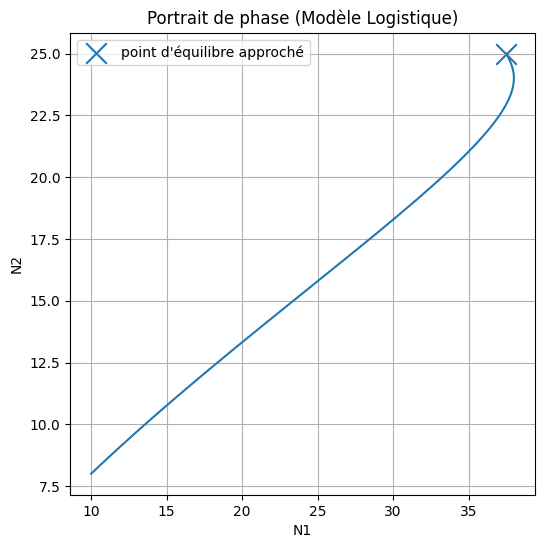

In [34]:
plt.figure(figsize=(6, 6))
plt.plot(N1, N2)

plt.xlabel("N1")
plt.ylabel("N2")
plt.title("Portrait de phase (Modèle Logistique)")
plt.scatter(N1_eq, N2_eq, marker='x', s=219, label="point d'équilibre approché")
plt.legend()
plt.grid(True)
plt.show()

## 3. Influence du pas de discrétisation

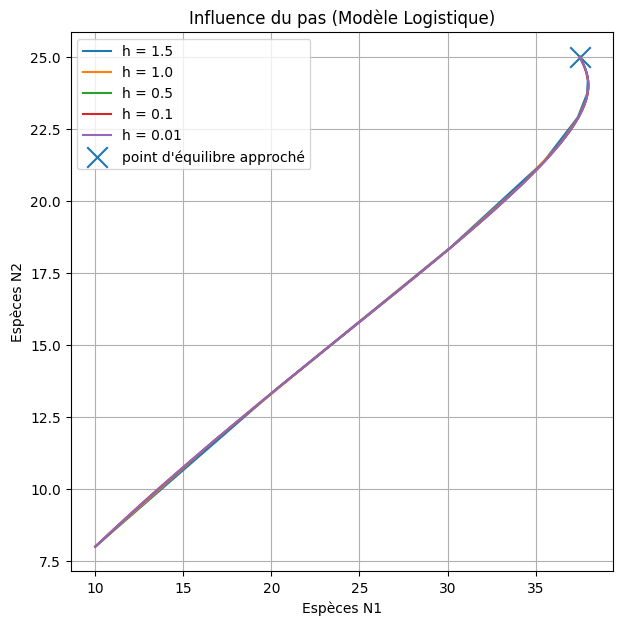

In [35]:
steps = [1.5, 1.0, 0.5, 0.1, 0.01]

plt.figure(figsize=(7, 7))

for h_test in steps:
    t_temp, y_temp = rk4(logistic_two_species, t0, y0_log, T, h_test, params_log)
    plt.plot(y_temp[:, 0], y_temp[:, 1], label=f"h = {h_test}")

plt.xlabel("Espèces N1")
plt.ylabel("Espèces N2")
plt.title("Influence du pas (Modèle Logistique)")
plt.scatter(N1_eq, N2_eq, marker='x', s=219, label="point d'équilibre approché")
plt.legend()
plt.grid(True)
plt.show()

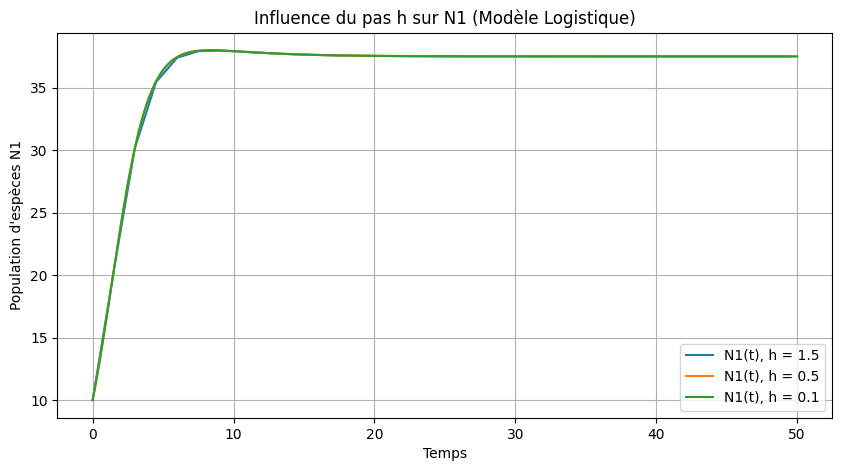

In [36]:
steps = [1.5, 0.5, 0.1]

plt.figure(figsize=(10, 5))

for h_test in steps:
    t_temp, y_temp = rk4(logistic_two_species, t0, y0_log, T, h_test, params_log)
    plt.plot(t_temp, y_temp[:, 0], label=f"N1(t), h = {h_test}")

plt.xlabel("Temps")
plt.ylabel("Population d'espèces N1")
plt.title("Influence du pas h sur N1 (Modèle Logistique)")
plt.legend()
plt.grid(True)
plt.show()

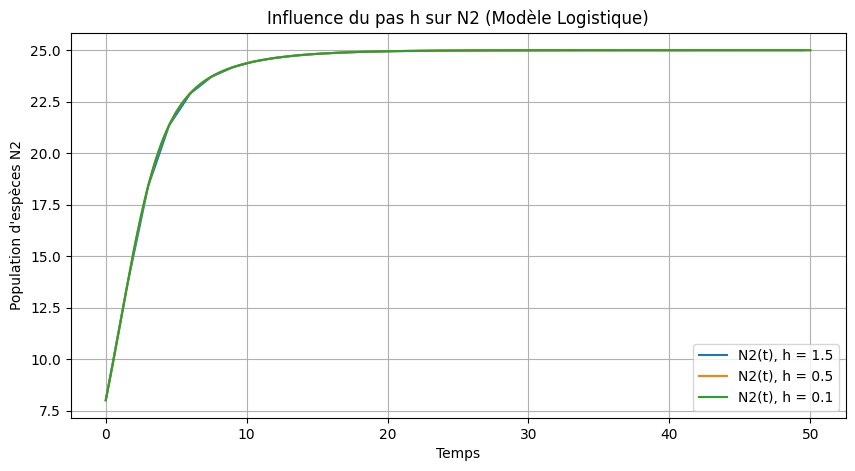

In [37]:
plt.figure(figsize=(10, 5))

for h_test in steps:
    t_temp, y_temp = rk4(logistic_two_species, t0, y0_log, T, h_test, params_log)
    plt.plot(t_temp, y_temp[:, 1], label=f"N2(t), h = {h_test}")

plt.xlabel("Temps")
plt.ylabel("Population d'espèces N2")
plt.title("Influence du pas h sur N2 (Modèle Logistique)")
plt.legend()
plt.grid(True)
plt.show()

## 4. Influence des conditions initiales

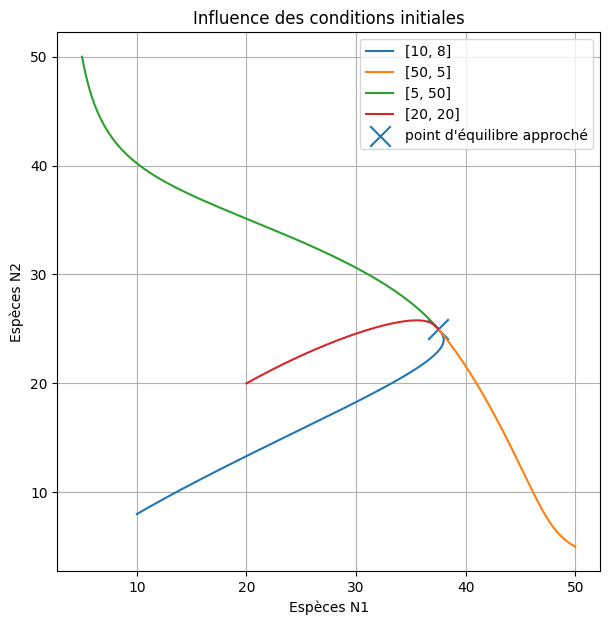

In [38]:
plt.figure(figsize=(7, 7))

tests = [[10,8], [50,5], [5,50], [20,20]]

for y0_log_test in tests:
    t, y = rk4(logistic_two_species, t0, y0_log_test, T, h, params_log)
    plt.plot(y[:,0], y[:,1], label = str(y0_log_test))

plt.xlabel("Espèces N1")
plt.ylabel("Espèces N2")
plt.title("Influence des conditions initiales")
plt.scatter(N1_eq, N2_eq, marker='x', s=219, label="point d'équilibre approché")
plt.legend()
plt.grid(True)
plt.show()

Observation: 
- Lorsque les conditions initiales changent, les trajectoires suivies par le système sont différentes.

- Certaines trajectoires se rapprochent du point d’équilibre approché plus rapidement que d’autres.

- Cela montre que les conditions initiales influencent fortement la dynamique transitoire du système.

- Pour les paramètres choisis, le système semble tendre vers une zone d’équilibre, mais la vitesse de convergence dépend de l’état initial.

## 5. Influence des taux de croissance

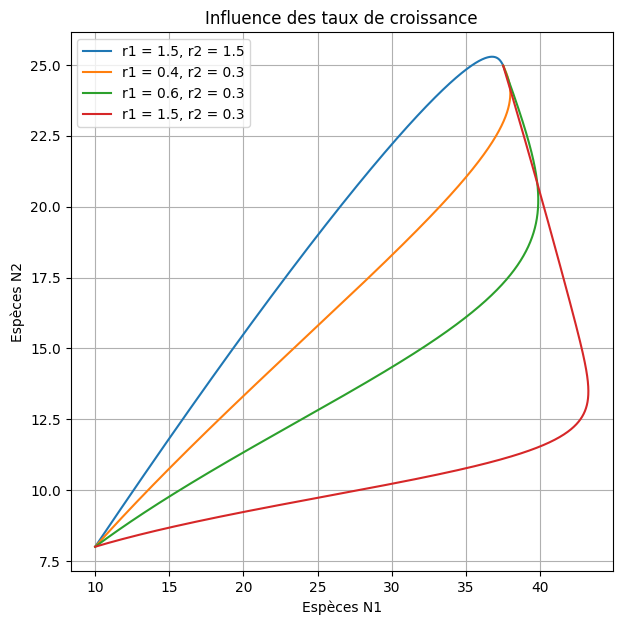

In [39]:
plt.figure(figsize=(7, 7))

growth_rates = [(1.5, 1.5), (0.4, 0.3), (0.6, 0.3),  (1.5, 0.3), ]

for r1_test, r2_test in growth_rates:
    t, y = rk4(logistic_two_species, t0, y0_log, T, h, (r1_test, r2_test, K1, K2, a12, a21))
    plt.plot(y[:,0], y[:,1], label = f"r1 = {r1_test}, r2 = {r2_test}")

plt.xlabel("Espèces N1")
plt.ylabel("Espèces N2")
plt.title("Influence des taux de croissance")
plt.legend()
plt.grid(True)
plt.show()

Observation: 
- Lorsque les taux de croissance $r_1$ et $r_2$ augmentent, les deux espèces évoluent plus rapidement.

- Les trajectoires se déplacent plus vite dans le plan de phase.

- On observe que des valeurs plus grandes de $r_1$ et $r_2$ donnent des variations plus rapides des populations avant la stabilisation.

- La forme générale des trajectoires reste cependant similaire, ce qui montre que les taux de croissance influencent surtout la vitesse d’évolution du système.

## 6. Influence des capacités de charge (carrying capacity)


[10.  8.]


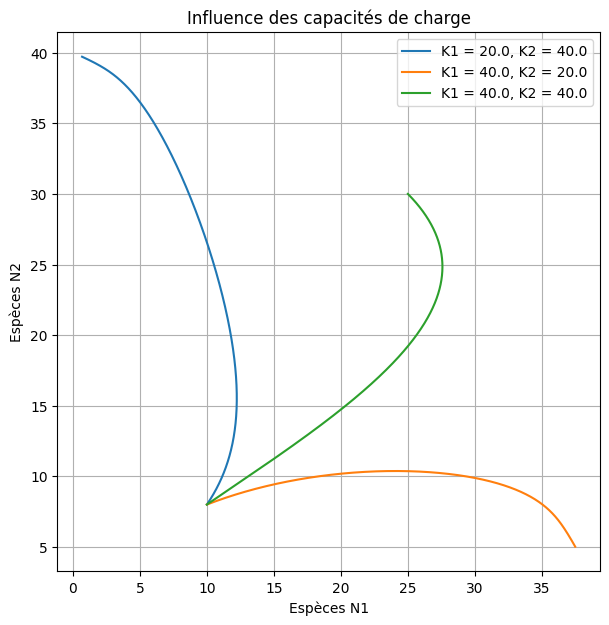

In [40]:
plt.figure(figsize=(7, 7))

capacities = [(20.0, 40.0), (40.0, 20.0), (40.0, 40.0)]
print(y0_log)

for K1_test, K2_test in capacities:
    t, y = rk4(logistic_two_species, t0, y0_log, T, h, (r1, r2, K1_test, K2_test, a12, a21))
    plt.plot(y[:,0], y[:,1], label = f"K1 = {K1_test}, K2 = {K2_test}")

plt.xlabel("Espèces N1")
plt.ylabel("Espèces N2")
plt.title("Influence des capacités de charge")
plt.legend()
plt.grid(True)
plt.show()

Observation: 
- Lorsque les capacités de charge $K_1$ et $K_2$ changent, les trajectoires sont nettement modifiées dans le plan de phase.

- Des valeurs plus grandes de $K_1$ ou $K_2$ permettent aux populations d’atteindre des niveaux plus élevés.

- Le point d’équilibre final est donc déplacé lorsque les capacités de charge varient.

- On observe ainsi que les capacités de charge influencent surtout l’amplitude des populations et la position de l’état final du système.

## 7. Influence de l’effet de compétition interspécifique

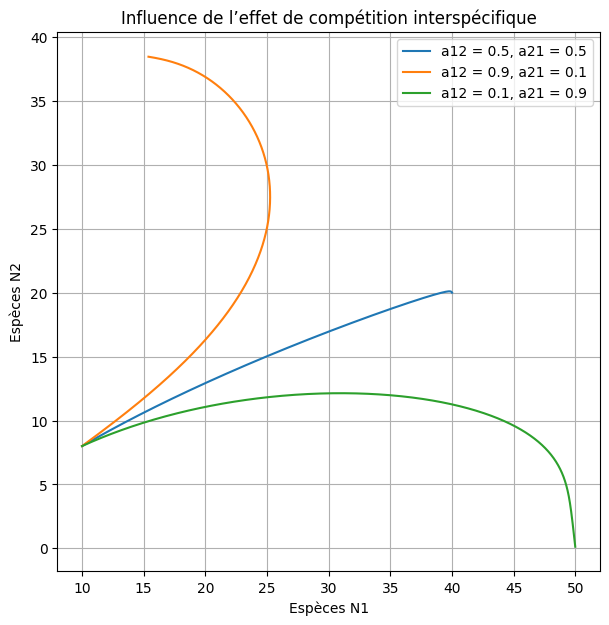

In [41]:
plt.figure(figsize=(7, 7))

competitions = [(0.5, 0.5), (0.9, 0.1), (0.1, 0.9)]

for a12_test, a21_test in competitions:
    t, y = rk4(logistic_two_species, t0, y0_log, T, h, (r1, r2, K1, K2, a12_test, a21_test))
    plt.plot(y[:,0], y[:,1], label = f"a12 = {a12_test}, a21 = {a21_test}")

plt.xlabel("Espèces N1")
plt.ylabel("Espèces N2")
plt.title("Influence de l’effet de compétition interspécifique")
plt.legend()
plt.grid(True)
plt.show()

Observation: 
- Lorsque les coefficients de compétition $a_{12}$ et $a_{21}$ augmentent, l’interaction négative entre les deux espèces devient plus forte.

- Si la compétition reste modérée, les deux espèces peuvent encore coexister et converger vers un équilibre commun.

- En revanche, si l’effet d’une espèce sur l’autre devient trop important, l’une des deux populations peut diminuer progressivement jusqu’à disparaître.

- Dans ce cas, on parle d’exclusion compétitive : une espèce domine le système tandis que l’autre est éliminée à long terme.

- Ainsi, les coefficients $a_{12}$ et $a_{21}$ déterminent non seulement la forme des trajectoires, mais aussi la possibilité de coexistence ou de disparition d’une espèce.

## VI. Analyse des résultats du Modèle Logistique

Contrairement au Modèle de Lotka-Volterra, les trajectoires du Modèle Logistique ne restent pas périodiques.

On observe au contraire une convergence progressive vers un état d’équilibre.

L’influence des paramètres montre que:

- Les taux de croissance $r_1$ et $r_2$ agissent surtout sur la rapidité d’évolution des populations.

- Les capacités de charge $K_1$ et $K_2$ modifient les niveaux de population atteints à long terme.

- Les coefficients de compétition $a_{12}$ et $a_{21}$ jouent un rôle central dans la coexistence des deux espèces.

Selon les valeurs choisies :
- les deux espèces peuvent converger vers un équilibre commun,
- ou bien une espèce peut prendre l’avantage sur l’autre.

L’influence du pas de temps montre aussi que :
- un pas plus grand dégrade la précision.
- un pas plus petit rend la solution numérique plus stable.

## VII. Comparaison des Modèles et Conclusion  

Le Modèle de Lotka-Volterra décrit une interaction de type proies-prédateurs. Il produit des oscillations périodiques des populations ainsi que des trajectoires fermées dans le plan de phase.

Le Modèle Logistique à deux espèces décrit au contraire une interaction de compétition interspécifique. Dans ce cas, les trajectoires convergent vers un équilibre et ne restent pas cycliques.

Ainsi:
- Lotka-Volterra : oscillations périodiques et cycles fermés
- Logistique : convergence vers un état d’équilibre

Ces différences montrent que le comportement du système dépend directement de la nature de l’interaction biologique modélisée.

Personal Remark: 
Les simulations montrent que le comportement du système dépend fortement des paramètres choisis, ce qui confirme l’importance de leur interprétation biologique.